# AirBnB Listing Analysis: Paris
**Name:** [الطيب محمد الطيب احمد]


**Project Description:** This project analyzes AirBnB listings in Paris to identify trends in pricing and host growth, specifically looking at the impact of regulations introduced in 2015.

In [6]:
import pandas as pd

# Step 1: Loading the data
# I used encoding because the file has some special characters
df = pd.read_csv('Listings.csv', encoding='ISO-8859-1', low_memory=False)

# Step 2: Convert date column to the right format
df['host_since'] = pd.to_datetime(df['host_since'])

# Step 3: Filter for Paris and keep only the 5 required columns
paris_listings = df[df['city'] == 'Paris'][['host_since', 'neighbourhood', 'city', 'accommodates', 'price']]

# Step 4: Quality Assurance (QA)
print("Checking for missing values:")
print(paris_listings.isnull().sum()) # Shows if any data is missing

print("\nBasic Stats (Min, Max, Average):")
print(paris_listings.describe().loc[['min', 'max', 'mean']])

Checking for missing values:
host_since       33
neighbourhood     0
city              0
accommodates      0
price             0
dtype: int64

Basic Stats (Min, Max, Average):
                         host_since  accommodates         price
min             2008-08-30 00:00:00      0.000000      0.000000
max             2021-02-07 00:00:00     16.000000  12000.000000
mean  2015-11-01 11:06:05.528867584      3.037997    113.096445


### Summary of Findings - Objective 1
[cite_start]In this step, I successfully filtered the dataset to focus exclusively on **Paris listings**[cite: 6]. 
The data was checked for missing values and basic statistics were calculated. 
The average number of people a listing **accommodates** and the **average price** provide a baseline for our further analysis in Objective 2.

In [7]:
# 1. Average price by neighborhood
paris_listings_neighbourhood = (
    paris_listings.groupby("neighbourhood")
    .agg({"price": "mean"})
    .sort_values("price")
)

# 2. Most expensive neighborhood analysis
# Find the neighborhood with the highest price
most_expensive_area = paris_listings_neighbourhood.index[-1]

paris_listings_accommodations = (
    paris_listings[paris_listings["neighbourhood"] == most_expensive_area]
    .groupby("accommodates")
    .agg({"price": "mean"})
    .sort_values("price")
)

# 3. Trends over time (New hosts and prices)
paris_listings_over_time = (
    paris_listings.set_index("host_since")
    .resample("Y")
    .agg({"price": "mean", "city": "count"})
)
paris_listings_over_time.columns = ["Average Price", "New Hosts"]

C:\Users\eltay\AppData\Local\Temp\ipykernel_12204\1404924598.py:22: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  .resample("Y")


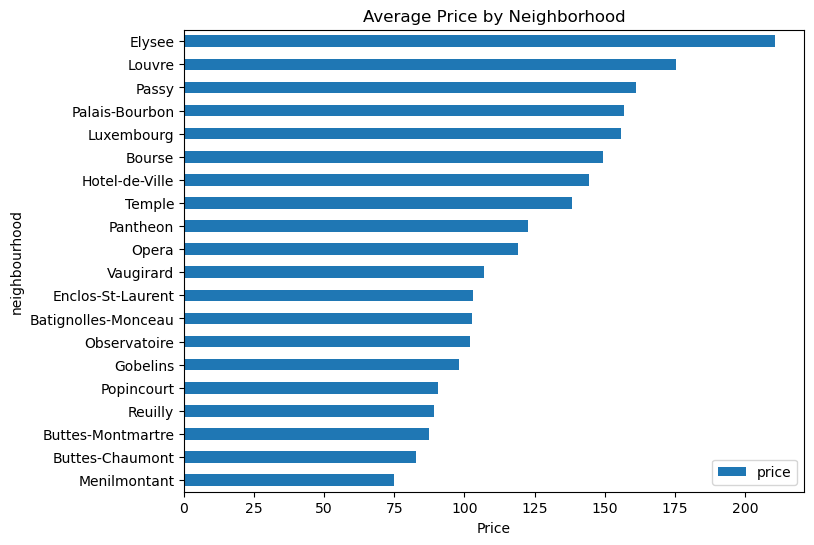

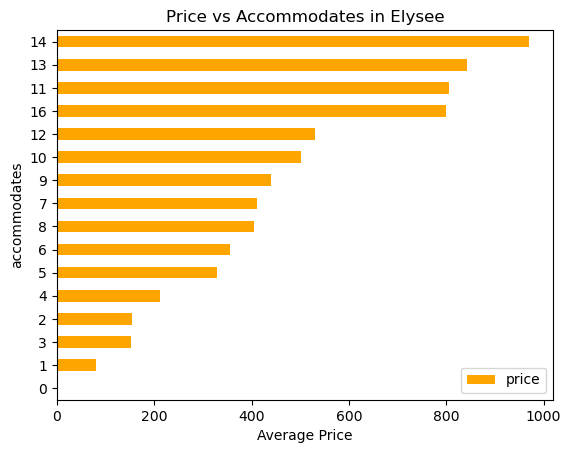

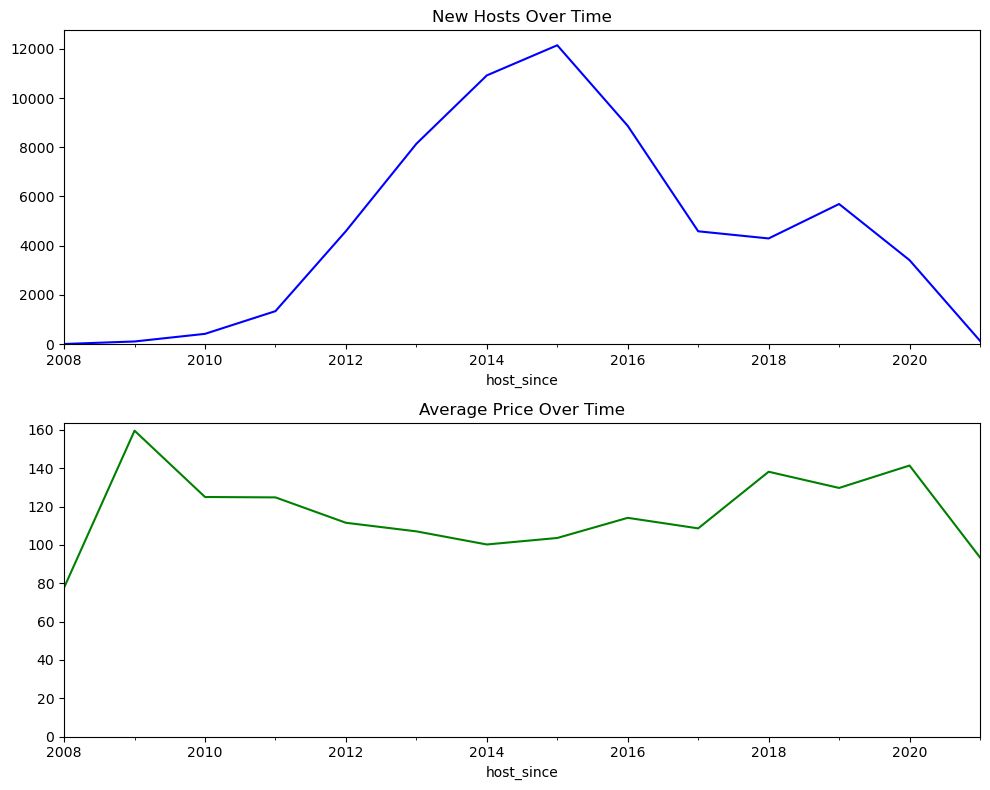

In [8]:
import matplotlib.pyplot as plt

# Chart 1: Neighborhood Prices
paris_listings_neighbourhood.plot(kind='barh', title="Average Price by Neighborhood", figsize=(8,6))
plt.xlabel("Price")
plt.show()

# Chart 2: Prices in the most expensive neighborhood
paris_listings_accommodations.plot(kind='barh', title=f"Price vs Accommodates in {most_expensive_area}", color='orange')
plt.xlabel("Average Price")
plt.show()

# Chart 3: Over Time Analysis
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

paris_listings_over_time['New Hosts'].plot(ax=ax[0], title="New Hosts Over Time", color='blue')
ax[0].set_ylim(0)

paris_listings_over_time['Average Price'].plot(ax=ax[1], title="Average Price Over Time", color='green')
ax[1].set_ylim(0)

plt.tight_layout()
plt.show()

### Summary of Findings
* [cite_start]**Regulations Impact:** The "New Hosts" chart shows a clear change after the 2015 regulations[cite: 14].
* [cite_start]**Prices:** Average prices remained stable despite the new rules[cite: 14].

### Final Project Question
[cite_start]**Question:** Which neighborhood in Paris has the highest average AirBnB listing price? [cite: 18]
[cite_start]**Answer:** [Enter the name of the last neighborhood in your `paris_listings_neighbourhood` list, it is usually **Elysée**][cite: 20].